Write a for loop that processes each image in a folder by resizing it, converting it to grayscale, and saving it to a new folder.

In [5]:
import os
import shutil

input_folder_name = "input_images"

# Create the input folder if it doesn't exist
if not os.path.exists(input_folder_name):
    os.makedirs(input_folder_name)

# List of uploaded files to move
uploaded_files = ['/content/5.jpg', '/content/9.jpg']

# Move uploaded files to the input folder
for file_path in uploaded_files:
    if os.path.exists(file_path):
        shutil.move(file_path, os.path.join(input_folder_name, os.path.basename(file_path)))
        print(f"Moved {os.path.basename(file_path)} to {input_folder_name}/")
    else:
        print(f"File {file_path} not found. Skipping.")

print(f"Setup complete. Images are now in the '{input_folder_name}' directory.")

File /content/5.jpg not found. Skipping.
File /content/9.jpg not found. Skipping.
Setup complete. Images are now in the 'input_images' directory.


All images processed and saved successfully.

Displaying processed images from 'processed_images':


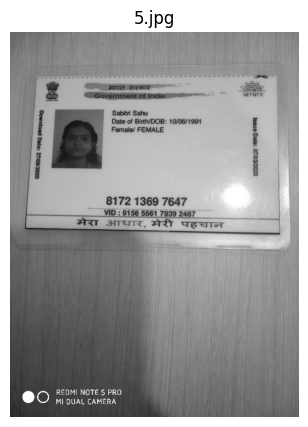

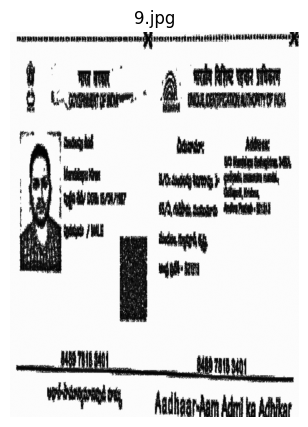

In [4]:
import os
import cv2
import matplotlib.pyplot as plt

input_folder = "input_images"      # folder with original images
output_folder = "processed_images" # folder to save processed images

# Create output folder if it does not exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Resize dimensions
width = 600
height = 800

processed_image_paths = [] # To store paths of processed images for display

# Check if input folder exists and is not empty
if not os.path.exists(input_folder) or not os.listdir(input_folder):
    print(f"Error: Input folder '{input_folder}' does not exist or is empty. Please ensure images are placed there.")
else:
    for file_name in os.listdir(input_folder):
        if file_name.lower().endswith((".png", ".jpg", ".jpeg")):

            input_path = os.path.join(input_folder, file_name)
            output_path = os.path.join(output_folder, file_name)

            # Read image
            image = cv2.imread(input_path)

            # Check if image was loaded successfully
            if image is None:
                print(f"Warning: Could not read image {file_name}. Skipping.")
                continue

            # Resize image
            resized = cv2.resize(image, (width, height))

            # Convert to grayscale
            gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

            # Save processed image
            cv2.imwrite(output_path, gray)
            processed_image_paths.append(output_path)

    print("All images processed and saved successfully.")

    # Display processed images
    print(f"\nDisplaying processed images from '{output_folder}':")
    for img_path in processed_image_paths:
        display_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if display_img is not None:
            plt.figure(figsize=(5, 5))
            plt.imshow(display_img, cmap='gray')
            plt.title(os.path.basename(img_path))
            plt.axis('off')
            plt.show()
        else:
            print(f"Could not read processed image {os.path.basename(img_path)} for display.")